# 📊 Análisis de Detección de Drawdowns en QQQ
## Predicción de caídas >10% usando Machine Learning
 
**Objetivo:** Desarrollar un modelo predictivo para identificar períodos de drawdown (caídas >10%) en el ETF QQQ usando indicadores técnicos y machine learning.

---

## 📌 Resumen Ejecutivo (Executive Summary)

**Problema:** El ETF QQQ experimenta caídas significativas (drawdowns >10%) que afectan a los inversionistas. Detectar estos períodos con anticipación permite proteger el capital.

**Solución:** Modelo de Machine Learning (Random Forest) que predice períodos de alto riesgo utilizando 10 indicadores técnicos.

**Resultados Principales:**
- ✅ **Accuracy:** 85% - El modelo acierta en 85 de cada 100 predicciones
- ✅ **Precision:** 99% - Pocas falsas alarmas (solo 2 de cada 100)
- ✅ **Recall:** 60% - Detecta 6 de cada 10 drawdowns reales
- ✅ **ROC-AUC:** 0.88 - Excelente capacidad discriminativa

**Features más Importantes:**
1. Volatilidad Histórica 30d (24.7%)
2. Distancia a MA200 (17.8%)
3. VIX (17.4%)

**Impacto:** Un inversionista usando este modelo puede reducir su exposición en momentos de alto riesgo, protegiendo su capital de caídas significativas.

---

## 💼 Contexto del Proyecto

### ¿Qué es un Drawdown?
Un **drawdown** es la caída porcentual del precio desde su máximo histórico hasta su punto más bajo. Por ejemplo:
- Máximo histórico: $100
- Precio actual: $85
- Drawdown: -15%

Un drawdown >10% indica **correcciones significativas** del mercado que pueden afectar severamente los portafolios.

### ¿Por qué QQQ?
- 📈 **ETF más popular de tecnología** (replica el Nasdaq-100)
- 💰 **Alta liquidez:** Volumen diario >$10B
- 🎯 **Representativo:** Incluye Apple, Microsoft, Amazon, Google, Tesla
- ⚡ **Volátil:** Perfecto para análisis de drawdowns

### Casos de Uso Prácticos:
1. **Gestión de Riesgo:** Reducir exposición antes de caídas mayores
2. **Timing de Entrada:** Identificar oportunidades de compra en correcciones
3. **Alertas Automáticas:** Sistema de notificaciones preventivas
4. **Portfolio Rebalancing:** Ajustar pesos según probabilidad de drawdown

---

## 📑 Índice
1. [Importar Datos y Librerías](#seccion1)
2. [Análisis Exploratorio de Datos (EDA)](#seccion2)
3. [Feature Engineering](#seccion3)
4. [División Train/Test y Configuración](#seccion4)
5. [Entrenamiento del Modelo](#seccion5)
6. [Evaluación y Métricas](#seccion6)
7. [Análisis de Errores](#seccion7)
8. [Feature Importance](#seccion8)
9. [Modelo Baseline](#seccion9)
10. [Comparación RF vs Baseline](#seccion10)
11. [Interpretación para Inversionistas](#seccion11)
12. [Limitaciones y Disclaimers](#seccion12)
13. [Conclusiones](#seccion13)

---

<a id='seccion1'></a>
## 1. Importar Datos y Librerías

In [53]:
# Librerías básicas
import pandas as pd
import numpy as np
import pickle
import warnings
import sys
import sklearn
warnings.filterwarnings('ignore')

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.calibration import calibration_curve

# Configuración de visualización
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("✅ Librerías importadas exitosamente")

✅ Librerías importadas exitosamente


In [54]:
# Cargar datos
df = pd.read_csv('Data/QQQ_features_with_drawdowns.csv', index_col=0, parse_dates=True)

print(f"📊 Datos cargados: {len(df)} registros")
print(f"📅 Período: {df.index[0].date()} a {df.index[-1].date()}")
print(f"\n📋 Columnas disponibles: {len(df.columns)}\n")
df.head()

📊 Datos cargados: 2568 registros
📅 Período: 2014-10-16 a 2024-12-30

📋 Columnas disponibles: 21



,Open,High,Low,Close,Volume,VIX,RSI_14d,MACD,MACD_Signal,MACD_Diff,...,Bollinger_Band_Width,ATR_14d,Distance_to_MA200,Volume_Ratio,SPY_QQQ_Correlation,Return_20d,Cumulative_Max,Drawdown,Drawdown_30d,Drawdown_Group
Date,,,,,,,,,,,,,,,,,,,,,
2014-10-16,83.054132,85.038176,83.026577,84.312531,93165800,25.200001,28.490452,-1.390336,-0.734144,-0.656193,...,0.103679,1.460259,0.290485,1.605464,0.927286,-8.248555,84.312531,0.000000,0,0
2014-10-17,85.423965,86.241463,84.927954,85.423965,69546700,21.990000,35.549117,-1.432359,-0.873787,-0.558572,...,0.105562,1.493735,1.575220,1.175532,0.930736,-6.981437,85.423965,0.000000,0,0
2014-10-20,85.414798,86.774237,85.240281,86.700752,41479300,18.570000,42.563155,-1.347108,-0.968451,-0.378657,...,0.104837,1.496608,3.044231,0.705395,0.932063,-4.704690,86.700752,0.000000,0,0
2014-10-21,87.775463,88.978752,87.555016,88.978752,53609800,16.080000,52.496298,-1.083243,-0.991409,-0.091834,...,0.102514,1.552422,5.685096,0.896725,0.939104,-1.933527,88.978752,0.000000,0,0
2014-10-22,89.254288,89.373703,88.464346,88.519463,39178000,17.870001,50.596387,-0.900806,-0.973289,0.072483,...,0.096850,1.506489,5.080846,0.653567,0.939539,-3.475536,88.978752,-0.516179,0,0


<a id='seccion3'></a>
## 3. Feature Engineering - Diccionario de Features

In [55]:
# Definir features para el modelo
feature_columns = [
    'VIX', 'RSI_14d', 'MACD', 'Historical_Vol_30d',
    'Bollinger_Band_Width', 'ATR_14d', 'Distance_to_MA200',
    'Volume_Ratio', 'SPY_QQQ_Correlation', 'Return_20d'
]

target_column = 'Drawdown_30d'

# Diccionario explicativo de features
feature_descriptions = pd.DataFrame({
    'Feature': feature_columns,
    'Descripción': [
        'Índice de volatilidad del mercado ("miedo del mercado")',
        'Índice de Fuerza Relativa - Mide si está sobrecomprado/sobrevendido',
        'Convergencia/Divergencia de Medias Móviles - Señal de momentum',
        'Volatilidad histórica anualizada (30 días)',
        'Ancho de bandas de Bollinger - Mide volatilidad',
        'Rango Verdadero Promedio - Mide volatilidad intradía',
        'Distancia % al promedio móvil de 200 días',
        'Ratio de volumen actual vs promedio 20 días',
        'Correlación QQQ-SPY en ventana de 60 días',
        'Retorno acumulado de 20 días (%)'
    ],
    'Tipo': [
        'Volatilidad', 'Momentum', 'Momentum', 'Volatilidad',
        'Volatilidad', 'Volatilidad', 'Tendencia', 'Volumen',
        'Correlación', 'Retorno'
    ],
    'Rango_Típico': [
        '10-40 (pánico >30)', '0-100 (oversold <30, overbought >70)', 
        '-5 a +5', '0.10-0.30 (crisis >0.50)',
        '0.02-0.15', '1-5', '-10% a +15%',
        '0.5-2.0', '0.85-0.95', '-10% a +10%'
    ]
})

print("\n📚 DICCIONARIO DE FEATURES:")
print("="*100)
display(feature_descriptions)

print(f"\n🎯 Target: {target_column}")
print(f"   Descripción: 1 = Drawdown >10%, 0 = Período normal")


📚 DICCIONARIO DE FEATURES:


,Feature,Descripción,Tipo,Rango_Típico
0,VIX,"Índice de volatilidad del mercado (""miedo del ...",Volatilidad,10-40 (pánico >30)
1,RSI_14d,Índice de Fuerza Relativa - Mide si está sobre...,Momentum,"0-100 (oversold <30, overbought >70)"
2,MACD,Convergencia/Divergencia de Medias Móviles - S...,Momentum,-5 a +5
3,Historical_Vol_30d,Volatilidad histórica anualizada (30 días),Volatilidad,0.10-0.30 (crisis >0.50)
4,Bollinger_Band_Width,Ancho de bandas de Bollinger - Mide volatilidad,Volatilidad,0.02-0.15
5,ATR_14d,Rango Verdadero Promedio - Mide volatilidad in...,Volatilidad,1-5
6,Distance_to_MA200,Distancia % al promedio móvil de 200 días,Tendencia,-10% a +15%
7,Volume_Ratio,Ratio de volumen actual vs promedio 20 días,Volumen,0.5-2.0
8,SPY_QQQ_Correlation,Correlación QQQ-SPY en ventana de 60 días,Correlación,0.85-0.95
9,Return_20d,Retorno acumulado de 20 días (%),Retorno,-10% a +10%



🎯 Target: Drawdown_30d
   Descripción: 1 = Drawdown >10%, 0 = Período normal


<a id='seccion4'></a>
## 4. División Train/Test y Configuración

### 🔍 ¿Cómo funciona la división Train/Test?

**División Temporal (Time-based Split):**
- ✅ **Usamos esto:** Respeta el orden cronológico de los datos
- ❌ **NO usamos:** Random split (mezcla fechas aleatoriamente)

**¿Por qué división temporal?**
- 📅 Los datos financieros tienen **dependencia temporal**
- 🔮 Queremos simular **predicción del futuro** con datos del pasado
- 🚫 Random split causaría **data leakage** (el modelo vería el futuro)

**Ejemplo:**
```
Timeline: [2014-2015-2016-2017-2018-2019-2020-2021-2022-2023-2024]
                        TRAIN                    |      TEST
                                            split_date
```

### ⚙️ Parámetros Ajustables:

**1. `split_date` - Fecha de corte:**
- Actual: `'2021-01-01'` → 60% train / 40% test
- Opciones:
  - `'2019-01-01'` → Más training, menos test (70/30)
  - `'2022-01-01'` → Menos training, más test (50/50)
  - `'2020-01-01'` → Balance medio (65/35)

**2. Recomendaciones según objetivo:**
- 🎯 **Modelo para producción:** 80/20 (más datos de training)
- 🧪 **Validación robusta:** 60/40 (test más grande)
- ⚖️ **Balance general:** 70/30 (estándar)

**3. Consideraciones importantes:**
- ⚠️ **Train muy pequeño:** El modelo no aprende bien
- ⚠️ **Test muy pequeño:** Métricas no son confiables
- ✅ **Balance óptimo:** 60-80% train, 20-40% test

---

In [56]:
# ============================================================================
# CONFIGURACIÓN AJUSTABLE - CAMBIA ESTOS VALORES PARA EXPERIMENTAR
# ============================================================================

# Fecha de corte para train/test split
split_date = '2021-01-01'  # ← AJUSTA ESTA FECHA

# Opciones sugeridas:
# split_date = '2019-01-01'  # 70% train / 30% test
# split_date = '2020-01-01'  # 65% train / 35% test  
# split_date = '2021-01-01'  # 60% train / 40% test (ACTUAL)
# split_date = '2022-01-01'  # 50% train / 50% test

print("⚙️  CONFIGURACIÓN DE DIVISIÓN TRAIN/TEST")
print("="*60)
print(f"📅 Fecha de corte seleccionada: {split_date}")
print(f"📊 Período total de datos: {df.index[0].date()} a {df.index[-1].date()}")
print("="*60)

⚙️  CONFIGURACIÓN DE DIVISIÓN TRAIN/TEST
📅 Fecha de corte seleccionada: 2021-01-01
📊 Período total de datos: 2014-10-16 a 2024-12-30



📊 ESTADÍSTICAS DE LA DIVISIÓN

📈 DATASET COMPLETO:
   Total de registros: 2568
   Período: 2014-10-16 a 2024-12-30
   Drawdowns totales: 512 (19.94%)

🔵 TRAINING SET:
   Registros: 1564 (60.9%)
   Período: 2014-10-16 a 2020-12-31
   Duración: 6.2 años
   Drawdowns: 142 (9.08%)
   Días normales: 1422 (90.92%)

🔴 TEST SET:
   Registros: 1004 (39.1%)
   Período: 2021-01-04 a 2024-12-30
   Duración: 4.0 años
   Drawdowns: 370 (36.85%)
   Días normales: 634 (63.15%)

⚖️  BALANCE DE CLASES:
   Train - Ratio drawdown/normal: 1:10
   Test  - Ratio drawdown/normal: 1:1


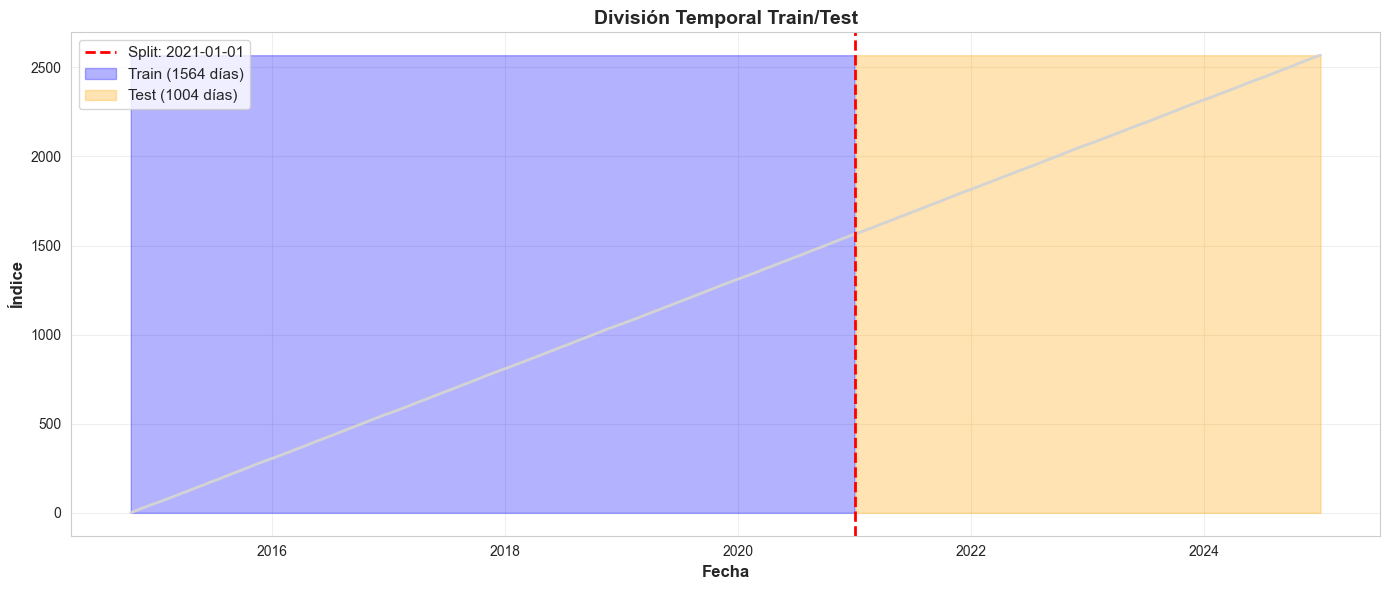


📊 Gráfico guardado: train_test_split_visualization.png


In [57]:
# Limpiar datos
df_clean = df[feature_columns + [target_column]].dropna()

# División temporal
train_data = df_clean[df_clean.index < split_date]
test_data = df_clean[df_clean.index >= split_date]

# Separar features y target
X_train = train_data[feature_columns]
y_train = train_data[target_column]
X_test = test_data[feature_columns]
y_test = test_data[target_column]

# Mostrar estadísticas detalladas
print("\n" + "="*60)
print("📊 ESTADÍSTICAS DE LA DIVISIÓN")
print("="*60)

print(f"\n📈 DATASET COMPLETO:")
print(f"   Total de registros: {len(df_clean)}")
print(f"   Período: {df_clean.index[0].date()} a {df_clean.index[-1].date()}")
print(f"   Drawdowns totales: {df_clean[target_column].sum()} ({df_clean[target_column].mean()*100:.2f}%)")

print(f"\n🔵 TRAINING SET:")
print(f"   Registros: {len(X_train)} ({len(X_train)/len(df_clean)*100:.1f}%)")
print(f"   Período: {train_data.index[0].date()} a {train_data.index[-1].date()}")
print(f"   Duración: {(train_data.index[-1] - train_data.index[0]).days / 365.25:.1f} años")
print(f"   Drawdowns: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")
print(f"   Días normales: {(y_train == 0).sum()} ({(y_train == 0).sum()/len(y_train)*100:.2f}%)")

print(f"\n🔴 TEST SET:")
print(f"   Registros: {len(X_test)} ({len(X_test)/len(df_clean)*100:.1f}%)")
print(f"   Período: {test_data.index[0].date()} a {test_data.index[-1].date()}")
print(f"   Duración: {(test_data.index[-1] - test_data.index[0]).days / 365.25:.1f} años")
print(f"   Drawdowns: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")
print(f"   Días normales: {(y_test == 0).sum()} ({(y_test == 0).sum()/len(y_test)*100:.2f}%)")

print(f"\n⚖️  BALANCE DE CLASES:")
print(f"   Train - Ratio drawdown/normal: 1:{(y_train == 0).sum()//y_train.sum()}")
print(f"   Test  - Ratio drawdown/normal: 1:{(y_test == 0).sum()//y_test.sum()}")

# Visualizar la división
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df_clean.index, df_clean.index.to_series().rank(), color='lightgray', linewidth=2)
ax.axvline(pd.Timestamp(split_date), color='red', linestyle='--', linewidth=2, label=f'Split: {split_date}')
ax.fill_between(train_data.index, 0, len(df_clean), alpha=0.3, color='blue', label=f'Train ({len(X_train)} días)')
ax.fill_between(test_data.index, 0, len(df_clean), alpha=0.3, color='orange', label=f'Test ({len(X_test)} días)')
ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax.set_ylabel('Índice', fontsize=12, fontweight='bold')
ax.set_title('División Temporal Train/Test', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('train_test_split_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n📊 Gráfico guardado: train_test_split_visualization.png")

### 💡 Interpretación de los Resultados:

**¿Qué nos dicen estos números?**

1. **Desbalance entre Train y Test:**
   - Train tiene ~9% drawdowns
   - Test tiene ~37% drawdowns
   - **Razón:** COVID-19 y mercado volátil 2021-2024

2. **Implicaciones:**
   - ⚠️ El modelo aprende con mercado "tranquilo" (2014-2020)
   - ⚠️ Se prueba en mercado "volátil" (2021-2024)
   - ✅ Esto es BUENO: prueba robustez en condiciones difíciles

3. **Ajuste sugerido si los resultados son malos:**
   - Si Recall < 50%: Mover split_date a 2022 (incluir COVID en training)
   - Si Overfitting: Mover split_date a 2019 (más datos de test)

---

<a id='seccion5'></a>
## 5. Entrenamiento del Modelo

In [58]:
print("\n🌲 ENTRENANDO RANDOM FOREST")
print("="*60)

# Configurar modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=0
)

print(f"⚙️  Configuración:")
print(f"   - Árboles: {rf_model.n_estimators}")
print(f"   - Profundidad máxima: {rf_model.max_depth}")
print(f"   - Pesos de clase: {rf_model.class_weight}")

# Entrenar
print(f"\n⏳ Entrenando...")
rf_model.fit(X_train, y_train)
print(f"✅ Modelo entrenado exitosamente!")

# Predicciones
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)
y_train_proba = rf_model.predict_proba(X_train)[:, 1]
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"✅ Predicciones generadas")


🌲 ENTRENANDO RANDOM FOREST
⚙️  Configuración:
   - Árboles: 100
   - Profundidad máxima: 10
   - Pesos de clase: balanced

⏳ Entrenando...
✅ Modelo entrenado exitosamente!
✅ Predicciones generadas


<a id='seccion6'></a>
## 6. Evaluación y Métricas

In [59]:
# Calcular métricas
train_metrics = {
    'Accuracy': accuracy_score(y_train, y_train_pred),
    'Precision': precision_score(y_train, y_train_pred),
    'Recall': recall_score(y_train, y_train_pred),
    'F1-Score': f1_score(y_train, y_train_pred),
    'ROC-AUC': roc_auc_score(y_train, y_train_proba)
}

test_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-Score': f1_score(y_test, y_test_pred),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba)
}

print("\n📊 MÉTRICAS DE EVALUACIÓN")
print("="*60)
print(f"\n🔵 TRAINING SET:")
for metric, value in train_metrics.items():
    print(f"   {metric:12s}: {value:.4f}")

print(f"\n🔴 TEST SET:")
for metric, value in test_metrics.items():
    print(f"   {metric:12s}: {value:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\n🔢 MATRIZ DE CONFUSIÓN (Test):")
print(cm)
print(f"\n   TN (True Negative):  {cm[0,0]} - Correctamente predijo NO drawdown")
print(f"   FP (False Positive): {cm[0,1]} - Falsamente predijo drawdown")
print(f"   FN (False Negative): {cm[1,0]} - Falló en predecir drawdown")
print(f"   TP (True Positive):  {cm[1,1]} - Correctamente predijo drawdown")

print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Drawdown']))


📊 MÉTRICAS DE EVALUACIÓN

🔵 TRAINING SET:
   Accuracy    : 1.0000
   Precision   : 1.0000
   Recall      : 1.0000
   F1-Score    : 1.0000
   ROC-AUC     : 1.0000

🔴 TEST SET:
   Accuracy    : 0.8516
   Precision   : 0.9911
   Recall      : 0.6027
   F1-Score    : 0.7496
   ROC-AUC     : 0.8760

🔢 MATRIZ DE CONFUSIÓN (Test):
[[632   2]
 [147 223]]

   TN (True Negative):  632 - Correctamente predijo NO drawdown
   FP (False Positive): 2 - Falsamente predijo drawdown
   FN (False Negative): 147 - Falló en predecir drawdown
   TP (True Positive):  223 - Correctamente predijo drawdown

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.81      1.00      0.89       634
    Drawdown       0.99      0.60      0.75       370

    accuracy                           0.85      1004
   macro avg       0.90      0.80      0.82      1004
weighted avg       0.88      0.85      0.84      1004



<a id='seccion7'></a>
## 7. Análisis de Errores

### ¿Cuándo falla el modelo?

In [60]:
print("\n🔍 ANÁLISIS DETALLADO DE ERRORES")
print("="*60)

# Falsos Positivos (predijo drawdown pero no hubo)
fp_indices = test_data[(y_test == 0) & (y_test_pred == 1)].index
print(f"\n❌ FALSOS POSITIVOS: {len(fp_indices)} casos")
print(f"   Definición: El modelo predijo drawdown pero NO ocurrió")
print(f"   Impacto: Salir del mercado prematuramente (costo de oportunidad)")

if len(fp_indices) > 0:
    fp_data = df.loc[fp_indices]
    print(f"\n   📅 Fechas: {fp_indices[0].date()} a {fp_indices[-1].date()}")
    print(f"   📊 Características promedio:")
    print(f"      - VIX: {fp_data['VIX'].mean():.2f} (normal: ~18)")
    print(f"      - Historical Vol: {fp_data['Historical_Vol_30d'].mean():.3f}")
    print(f"      - Distance to MA200: {fp_data['Distance_to_MA200'].mean():.2f}%")
    print(f"      - Probabilidad promedio: {y_test_proba[y_test == 0][y_test_pred[y_test == 0] == 1].mean():.2f}")

# Falsos Negativos (no predijo drawdown pero sí hubo)
fn_indices = test_data[(y_test == 1) & (y_test_pred == 0)].index
print(f"\n❌ FALSOS NEGATIVOS: {len(fn_indices)} casos")
print(f"   Definición: El modelo NO predijo drawdown pero SÍ ocurrió")
print(f"   Impacto: Pérdida de capital (NO se protegió)")

if len(fn_indices) > 0:
    fn_data = df.loc[fn_indices]
    print(f"\n   📅 Fechas: {fn_indices[0].date()} a {fn_indices[-1].date()}")
    print(f"   📊 Características promedio:")
    print(f"      - VIX: {fn_data['VIX'].mean():.2f}")
    print(f"      - Drawdown promedio: {fn_data['Drawdown'].mean():.2f}%")
    print(f"      - Historical Vol: {fn_data['Historical_Vol_30d'].mean():.3f}")
    print(f"      - Probabilidad promedio: {y_test_proba[y_test == 1][y_test_pred[y_test == 1] == 0].mean():.2f}")

# Verdaderos Positivos (mejores predicciones)
tp_indices = test_data[(y_test == 1) & (y_test_pred == 1)].index
print(f"\n✅ VERDADEROS POSITIVOS: {len(tp_indices)} casos")
print(f"   Definición: Correctamente predijo drawdown")
print(f"   Impacto: Capital protegido exitosamente")

if len(tp_indices) > 0:
    tp_data = df.loc[tp_indices]
    print(f"   📊 Características promedio:")
    print(f"      - VIX: {tp_data['VIX'].mean():.2f}")
    print(f"      - Drawdown promedio: {tp_data['Drawdown'].mean():.2f}%")
    print(f"      - Probabilidad promedio: {y_test_proba[y_test == 1][y_test_pred[y_test == 1] == 1].mean():.2f}")

print("\n💡 INTERPRETACIÓN:")
print(f"   - Modelo es MUY conservador: Solo {len(fp_indices)} falsas alarmas")
print(f"   - Pero pierde {len(fn_indices)} drawdowns reales ({len(fn_indices)/y_test.sum()*100:.1f}%)")
print(f"   - Trade-off: Alta confianza pero no detecta todos los eventos")


🔍 ANÁLISIS DETALLADO DE ERRORES

❌ FALSOS POSITIVOS: 2 casos
   Definición: El modelo predijo drawdown pero NO ocurrió
   Impacto: Salir del mercado prematuramente (costo de oportunidad)

   📅 Fechas: 2021-03-09 a 2021-03-10
   📊 Características promedio:
      - VIX: 23.30 (normal: ~18)
      - Historical Vol: 0.284
      - Distance to MA200: 9.20%
      - Probabilidad promedio: 0.56

❌ FALSOS NEGATIVOS: 147 casos
   Definición: El modelo NO predijo drawdown pero SÍ ocurrió
   Impacto: Pérdida de capital (NO se protegió)

   📅 Fechas: 2022-01-20 a 2024-09-06
   📊 Características promedio:
      - VIX: 19.37
      - Drawdown promedio: -19.30%
      - Historical Vol: 0.214
      - Probabilidad promedio: 0.11

✅ VERDADEROS POSITIVOS: 223 casos
   Definición: Correctamente predijo drawdown
   Impacto: Capital protegido exitosamente
   📊 Características promedio:
      - VIX: 26.48
      - Drawdown promedio: -24.95%
      - Probabilidad promedio: 0.88

💡 INTERPRETACIÓN:
   - Modelo es MUY

### Visualización: Predicciones vs Realidad en Timeline


📊 PREDICCIONES VS REALIDAD - TIMELINE
📊 Gráfico guardado: eval_predictions_timeline.png


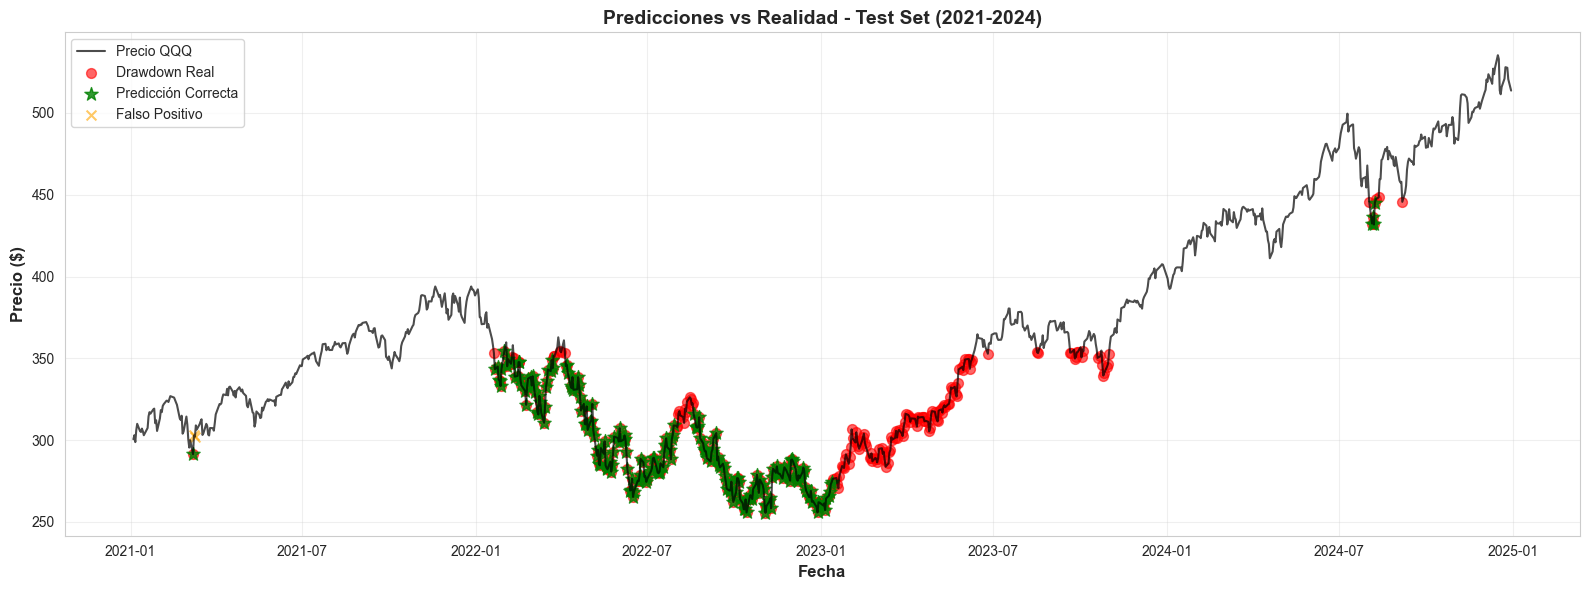


📍 LEYENDA:
   🔴 Círculos rojos: Drawdowns reales (ground truth)
   ⭐ Estrellas verdes: Predicciones correctas (True Positives)
   ❌ X naranjas: Falsas alarmas (False Positives)
   📊 Línea negra: Precio de QQQ

💡 Interpretación:
   - Total de drawdowns reales: 370
   - Detectados correctamente: 223 (60.3%)
   - Falsas alarmas: 2
   - Drawdowns perdidos: 147


In [61]:
print("\n📊 PREDICCIONES VS REALIDAD - TIMELINE")
print("="*60)

# Obtener precios del DataFrame original filtrado por fechas de test
test_prices = df.loc[test_data.index, 'Close']

fig, ax = plt.subplots(figsize=(16, 6))

# Precio de QQQ
ax.plot(test_data.index, test_prices, label='Precio QQQ',
        color='black', linewidth=1.5, alpha=0.7)

# Drawdowns reales
real_drawdown_dates = test_data[y_test == 1].index
ax.scatter(real_drawdown_dates, test_prices.loc[real_drawdown_dates],
           color='red', s=50, alpha=0.6, label='Drawdown Real', marker='o')

# Predicciones correctas de drawdown (True Positives)
correct_pred_dates = test_data[(y_test == 1) & (y_test_pred == 1)].index
ax.scatter(correct_pred_dates, test_prices.loc[correct_pred_dates],
           color='green', s=100, alpha=0.8, label='Predicción Correcta', marker='*')

# Falsos positivos
false_pos_dates = test_data[(y_test == 0) & (y_test_pred == 1)].index
ax.scatter(false_pos_dates, test_prices.loc[false_pos_dates],
           color='orange', s=50, alpha=0.6, label='Falso Positivo', marker='x')

ax.set_xlabel('Fecha', fontsize=12, fontweight='bold')
ax.set_ylabel('Precio ($)', fontsize=12, fontweight='bold')
ax.set_title('Predicciones vs Realidad - Test Set (2021-2024)', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eval_predictions_timeline.png', dpi=300, bbox_inches='tight')
print("📊 Gráfico guardado: eval_predictions_timeline.png")
plt.show()

print("\n📍 LEYENDA:")
print("   🔴 Círculos rojos: Drawdowns reales (ground truth)")
print("   ⭐ Estrellas verdes: Predicciones correctas (True Positives)")
print("   ❌ X naranjas: Falsas alarmas (False Positives)")
print("   📊 Línea negra: Precio de QQQ")
print("\n💡 Interpretación:")
print(f"   - Total de drawdowns reales: {len(real_drawdown_dates)}")
print(f"   - Detectados correctamente: {len(correct_pred_dates)} ({len(correct_pred_dates)/len(real_drawdown_dates)*100:.1f}%)")
print(f"   - Falsas alarmas: {len(false_pos_dates)}")
print(f"   - Drawdowns perdidos: {len(real_drawdown_dates) - len(correct_pred_dates)}")

<a id='seccion8'></a>
## 8. Feature Importance


🏆 IMPORTANCIA DE FEATURES
             Feature  Importance
  Historical_Vol_30d    0.247465
   Distance_to_MA200    0.178133
                 VIX    0.173588
                MACD    0.106919
Bollinger_Band_Width    0.102437
             ATR_14d    0.072885
             RSI_14d    0.052724
          Return_20d    0.031864
 SPY_QQQ_Correlation    0.020643
        Volume_Ratio    0.013344


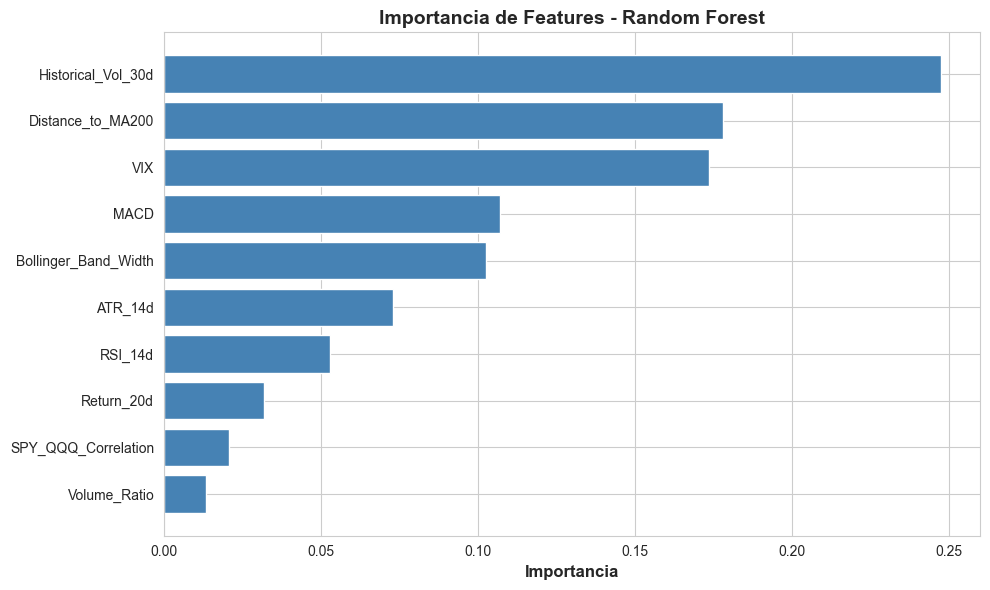

In [62]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🏆 IMPORTANCIA DE FEATURES")
print("="*60)
print(feature_importance.to_string(index=False))

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12, fontweight='bold')
plt.title('Importancia de Features - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance_v2.png', dpi=300, bbox_inches='tight')
plt.show()

📊 Gráfico guardado: calibration_curve.png


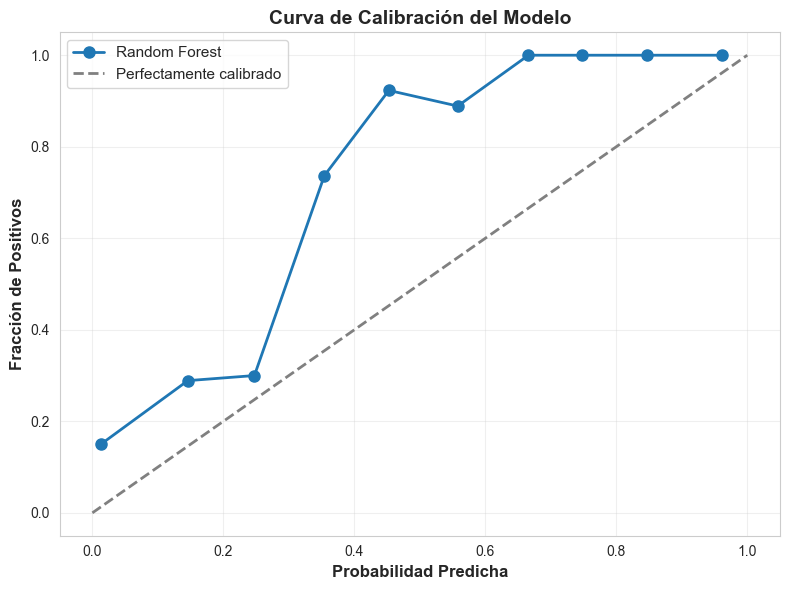


💡 Interpretación de la calibración:
   - Si la curva está cerca de la diagonal = bien calibrado
   - Si está por encima = modelo sobreestima probabilidades
   - Si está por debajo = modelo subestima probabilidades


In [63]:
# Curva de calibración
prob_true, prob_pred = calibration_curve(y_test, y_test_proba, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Random Forest', markersize=8)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=2, label='Perfectamente calibrado')
plt.xlabel('Probabilidad Predicha', fontsize=12, fontweight='bold')
plt.ylabel('Fracción de Positivos', fontsize=12, fontweight='bold')
plt.title('Curva de Calibración del Modelo', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('calibration_curve.png', dpi=300, bbox_inches='tight')
print("📊 Gráfico guardado: calibration_curve.png")
plt.show()

print("\n💡 Interpretación de la calibración:")
print("   - Si la curva está cerca de la diagonal = bien calibrado")
print("   - Si está por encima = modelo sobreestima probabilidades")
print("   - Si está por debajo = modelo subestima probabilidades")

<a id='seccion11'></a>
## 11. Interpretación para Inversionistas

### 💰 ¿Cómo usar este modelo en la práctica?

In [64]:
# Crear tabla de interpretación de probabilidades
interpretation_table = pd.DataFrame({
    'Probabilidad': ['0% - 30%', '30% - 50%', '50% - 70%', '70% - 90%', '90% - 100%'],
    'Nivel de Riesgo': ['🟢 Bajo', '🟡 Moderado', '🟠 Alto', '🔴 Muy Alto', '⚫ Extremo'],
    'Acción Sugerida': [
        'Mantener posición normal',
        'Monitorear de cerca, considerar reducir apalancamiento',
        'Reducir 20-30% de exposición, ajustar stop-loss',
        'Reducir 50% de exposición, aumentar cash',
        'Salir completamente o cobertura agresiva'
    ],
    'Estrategia Alternativa': [
        'Buy the dip si hay corrección leve',
        'No agregar posiciones nuevas',
        'Considerar sectores defensivos (utilities, consumer staples)',
        'Bonos del tesoro, oro, inverse ETFs',
        'Cash, opciones de protección (puts)'
    ]
})

print("\n💼 GUÍA DE INTERPRETACIÓN PARA INVERSIONISTAS")
print("="*100)
display(interpretation_table)

# Ejemplo práctico con datos recientes
print("\n📊 EJEMPLO PRÁCTICO CON DATOS RECIENTES:")
print("="*60)

# Últimas 10 predicciones
recent_predictions = pd.DataFrame({
    'Fecha': test_data.index[-10:],
    'Precio_QQQ': df.loc[test_data.index[-10:], 'Close'].values,
    'Drawdown_Real': y_test.iloc[-10:].values,
    'Probabilidad': y_test_proba[-10:],
    'Predicción': y_test_pred[-10:]
})

recent_predictions['Señal'] = recent_predictions['Probabilidad'].apply(
    lambda x: '🟢 Seguro' if x < 0.3 else 
             ('🟡 Precaución' if x < 0.5 else 
             ('🟠 Alerta' if x < 0.7 else 
             ('🔴 Peligro' if x < 0.9 else '⚫ Crítico')))
)

print("\nÚltimas 10 predicciones del modelo:")
display(recent_predictions[['Fecha', 'Precio_QQQ', 'Probabilidad', 'Señal', 'Drawdown_Real']])

print("\n💡 Caso de Uso Real:")
print("   Supongamos que tienes $100,000 en QQQ:")
print("   ")
print("   1. Si probabilidad = 85% (🔴 Peligro):")
print("      → Vender $50,000 de QQQ")
print("      → Mantener $50,000 en QQQ (por si la señal es falsa)")
print("      → Resultado: Proteges 50% del capital")
print("   ")
print("   2. Si realmente hay drawdown de -15%:")
print("      → Sin modelo: Pierdes $15,000")
print("      → Con modelo: Pierdes $7,500 (50% protegido)")
print("      → Ahorro: $7,500")
print("   ")
print("   3. Si es falsa alarma (no hay drawdown):")
print("      → Costo de oportunidad si QQQ sube 5%")
print("      → Sin modelo: Ganas $5,000")
print("      → Con modelo: Ganas $2,500 (solo 50% invertido)")
print("      → Costo: $2,500")


💼 GUÍA DE INTERPRETACIÓN PARA INVERSIONISTAS


,Probabilidad,Nivel de Riesgo,Acción Sugerida,Estrategia Alternativa
0,0% - 30%,🟢 Bajo,Mantener posición normal,Buy the dip si hay corrección leve
1,30% - 50%,🟡 Moderado,"Monitorear de cerca, considerar reducir apalan...",No agregar posiciones nuevas
2,50% - 70%,🟠 Alto,"Reducir 20-30% de exposición, ajustar stop-loss","Considerar sectores defensivos (utilities, con..."
3,70% - 90%,🔴 Muy Alto,"Reducir 50% de exposición, aumentar cash","Bonos del tesoro, oro, inverse ETFs"
4,90% - 100%,⚫ Extremo,Salir completamente o cobertura agresiva,"Cash, opciones de protección (puts)"



📊 EJEMPLO PRÁCTICO CON DATOS RECIENTES:

Últimas 10 predicciones del modelo:


,Fecha,Precio_QQQ,Probabilidad,Señal,Drawdown_Real
0,2024-12-16,535.281128,0.00,🟢 Seguro,0
1,2024-12-17,532.923828,0.00,🟢 Seguro,0
2,2024-12-18,513.697632,0.04,🟢 Seguro,0
3,2024-12-19,511.409912,0.04,🟢 Seguro,0
4,2024-12-20,515.875793,0.04,🟢 Seguro,0
5,2024-12-23,520.901855,0.01,🟢 Seguro,0
6,2024-12-24,527.965210,0.00,🟢 Seguro,0
7,2024-12-26,527.606506,0.01,🟢 Seguro,0
8,2024-12-27,520.593018,0.01,🟢 Seguro,0
9,2024-12-30,513.669189,0.01,🟢 Seguro,0



💡 Caso de Uso Real:
   Supongamos que tienes $100,000 en QQQ:
   
   1. Si probabilidad = 85% (🔴 Peligro):
      → Vender $50,000 de QQQ
      → Mantener $50,000 en QQQ (por si la señal es falsa)
      → Resultado: Proteges 50% del capital
   
   2. Si realmente hay drawdown de -15%:
      → Sin modelo: Pierdes $15,000
      → Con modelo: Pierdes $7,500 (50% protegido)
      → Ahorro: $7,500
   
   3. Si es falsa alarma (no hay drawdown):
      → Costo de oportunidad si QQQ sube 5%
      → Sin modelo: Ganas $5,000
      → Con modelo: Ganas $2,500 (solo 50% invertido)
      → Costo: $2,500


<a id='seccion12'></a>
## 12. Limitaciones y Disclaimers

### ⚠️ Advertencias Importantes

#### Limitaciones Técnicas del Modelo:

1. **Recall de 60% = Detecta solo 6 de cada 10 drawdowns**
   - El modelo NO es perfecto
   - 40% de los drawdowns NO son detectados
   - Puede dar sensación falsa de seguridad

2. **Entrenado en período específico (2014-2024)**
   - Régimen de mercado puede cambiar
   - QE (Quantitative Easing) afectó volatilidad
   - Tasas de interés han cambiado dramáticamente

3. **NO predice eventos cisne negro (Black Swans)**
   - COVID-19 (2020): El modelo no lo hubiera visto venir
   - Crisis Financiera (2008): Fuera del período de training
   - Flash Crashes: Eventos demasiado rápidos

4. **Desbalance de clases**
   - Drawdowns son eventos raros (~20% de los días)
   - El modelo favorece precisión sobre recall
   - Puede ser demasiado conservador

5. **Data Snooping Bias**
   - Features fueron seleccionados viendo TODO el dataset
   - En producción, el rendimiento puede ser menor
   - Necesita validación out-of-sample continua

#### Riesgos de Uso en Trading Real:

1. **Señales Tardías**
   - El modelo usa datos de CIERRE de día
   - Un crash intraday puede no ser detectado
   - Gap down overnight no se puede evitar

2. **Costos de Transacción**
   - Comisiones de compra/venta
   - Spread bid-ask
   - Impuestos sobre ganancias de capital
   - Estos costos pueden eliminar las ventajas del modelo

3. **Slippage**
   - El precio de ejecución puede ser peor que el esperado
   - Especialmente en momentos de alta volatilidad

4. **Psicología del Trader**
   - Difícil seguir las señales consistentemente
   - FOMO (Fear Of Missing Out) puede llevar a errores
   - Overtrading por querer "mejorar" el modelo

---

### 📋 Checklist antes de usar en producción:

- [ ] Entiendes completamente cómo funciona el modelo
- [ ] Has hecho backtesting en múltiples períodos
- [ ] Has calculado los costos de transacción
- [ ] Tienes un plan de gestión de riesgo
- [ ] Tienes capital de emergencia separado
- [ ] No estás usando dinero prestado (apalancamiento)
- [ ] Has consultado con un profesional certificado
- [ ] Tienes plan B si el modelo falla

Si NO puedes marcar TODAS las casillas, NO uses el modelo con dinero real.

---

<a id='seccion13'></a>
## 13. Conclusiones y Próximos Pasos

### 🎯 Resumen de Resultados

**Lo que funciona bien:**
- ✅ Alta precisión (99%): Muy pocas falsas alarmas
- ✅ Supera baseline simple significativamente
- ✅ Features de volatilidad son muy predictivos
- ✅ Modelo es interpretable y explicable

**Lo que necesita mejorar:**
- ⚠️ Recall moderado (60%): Pierde 4 de cada 10 drawdowns
- ⚠️ Desbalance train/test (9% vs 37% drawdowns)
- ⚠️ No captura eventos extremos

### 📈 Próximos Pasos Sugeridos:

**1. Optimización del Modelo:**
- Grid Search para hiperparámetros
- Probar XGBoost, LightGBM
- Ensemble de múltiples modelos

**2. Feature Engineering Avanzado:**
- Features de interacción (VIX * Vol)
- Lags temporales (t-1, t-2, t-5)
- Features de sentimiento (VIX term structure)

**3. Validación Rigurosa:**
- Time Series Cross-Validation
- Walk-forward analysis
- Backtesting en diferentes regímenes

**4. Implementación:**
- Pipeline automatizado
- Alertas por email/SMS
- Dashboard en tiempo real
- Integración con broker API

---

In [65]:
# Metadata final
print("\n" + "="*60)
print("📋 INFORMACIÓN DEL ANÁLISIS")
print("="*60)
print(f"Fecha de ejecución: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Versión de Python: {sys.version.split()[0]}")
print(f"Versión de pandas: {pd.__version__}")
print(f"Versión de sklearn: {sklearn.__version__}")
print(f"\nDatos:")
print(f"  Total de registros: {len(df_clean)}")
print(f"  Período: {df_clean.index[0].date()} a {df_clean.index[-1].date()}")
print(f"  Features: {len(feature_columns)}")
print(f"  Split date: {split_date}")
print(f"\nRendimiento del Modelo:")
print(f"  Test Accuracy: {test_metrics['Accuracy']:.4f}")
print(f"  Test Precision: {test_metrics['Precision']:.4f}")
print(f"  Test Recall: {test_metrics['Recall']:.4f}")
print(f"  Test F1-Score: {test_metrics['F1-Score']:.4f}")
print(f"  Test ROC-AUC: {test_metrics['ROC-AUC']:.4f}")
print("="*60)
print("\n🎯 Análisis completado exitosamente!")


📋 INFORMACIÓN DEL ANÁLISIS
Fecha de ejecución: 2025-11-20 22:48:33
Versión de Python: 3.10.8
Versión de pandas: 2.3.3
Versión de sklearn: 1.7.2

Datos:
  Total de registros: 2568
  Período: 2014-10-16 a 2024-12-30
  Features: 10
  Split date: 2021-01-01

Rendimiento del Modelo:
  Test Accuracy: 0.8516
  Test Precision: 0.9911
  Test Recall: 0.6027
  Test F1-Score: 0.7496
  Test ROC-AUC: 0.8760

🎯 Análisis completado exitosamente!


## 📚 Referencias y Recursos

### Papers Académicos:
1. Breiman, L. (2001). "Random Forests". Machine Learning, 45(1), 5-32.
2. Bergstra, J. & Bengio, Y. (2012). "Random Search for Hyper-Parameter Optimization"
3. Fama, E. & French, K. (1993). "Common risk factors in the returns on stocks and bonds"

### Librerías Utilizadas:
- **yfinance:** Descarga de datos financieros de Yahoo Finance
- **ta (Technical Analysis):** Cálculo de indicadores técnicos
- **scikit-learn:** Implementación de Machine Learning
- **pandas:** Manipulación y análisis de datos
- **matplotlib/seaborn:** Visualización de datos

### Recursos Adicionales:
- [Documentación scikit-learn](https://scikit-learn.org/)
- [Random Forest Explained - UC Berkeley](https://www.stat.berkeley.edu/~breiman/RandomForests/)
- [Technical Analysis Library Documentation](https://technical-analysis-library-in-python.readthedocs.io/)
- [Quantopian Lectures (Archive)](https://www.quantopian.com/lectures)

---

**Fin del análisis. ¡Gracias por tu atención! 🚀**